In [21]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('mnist.npz')
X_train = data['x_train'].reshape(-1, 784) / 255.0 # (60000, 784)
Y_train = data['y_train'] # (60000,)
X_test = data['x_test'].reshape(-1, 784) / 255.0 # (10000, 784)
Y_test = data['y_test'] # (10000,)
print("Training data shape:", X_train.shape)
print("Test data shape:    ", X_test.shape)

Training data shape: (60000, 784)
Test data shape:     (10000, 784)


In [13]:
# Layer 1 weights and biases: input (784) -> hidden layer 1 (128)
W1 = np.random.uniform(-0.5, 0.5, (784, 128))   # shape: (784, 128)
b1 = np.zeros((1, 128))                          # shape: (1, 128)

# Layer 2 weights and biases: hidden layer 1 (128) -> hidden layer 2 (64)
W2 = np.random.uniform(-0.5, 0.5, (128, 64))    # shape: (128, 64)
b2 = np.zeros((1, 64))                           # shape: (1, 64)

# Layer 3 weights and biases: hidden layer 2 (64) -> output layer (10)
W3 = np.random.uniform(-0.5, 0.5, (64, 10))     # shape: (64, 10)
b3 = np.zeros((1, 10))                           # shape: (1, 10)

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)
print("W3 shape:", W3.shape)

W1 shape: (784, 128)
W2 shape: (128, 64)
W3 shape: (64, 10)


In [11]:
def to_one_hot(labels, num_classes=10):
    # Create a zero matrix of shape (number of samples, 10)
    one_hot = np.zeros((labels.shape[0], num_classes))
    # Place a 1 in the column matching each label
    one_hot[np.arange(labels.shape[0]), labels] = 1
    return one_hot

# Convert training and test labels to one-hot format
Y_train_oh = to_one_hot(Y_train)   # shape: (60000, 10)
Y_test_oh  = to_one_hot(Y_test)    # shape: (10000, 10)

In [4]:
def sigmoid(z):
    # YOUR CODE HERE
    # Hint: use np.clip(z, -500, 500) to avoid overflow
    z_clipped = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z_clipped))
def sigmoid_derivative(a):
    # YOUR CODE HERE
    # Hint: you derived this in Task 3 - express it in terms of a
    return a * (1.0 - a)

In [15]:
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    # Layer 1
    Z1 = X @ W1 + b1 # YOUR CODE (weighted sum: X @ W1 + b1)
    A1 = sigmoid(Z1) # YOUR CODE (sigmoid activation)
    # Layer 2
    Z2 = A1 @ W2 + b2 # YOUR CODE
    A2 = sigmoid(Z2) # YOUR CODE
    # Output layer
    Z3 = A2 @ W3 + b3 # YOUR CODE
    A3 = sigmoid(Z3) # YOUR CODE
    return Z1, A1, Z2, A2, Z3, A3

In [7]:
def mse_loss(Y_true, Y_pred):
    # YOUR CODE HERE
    # Y_true: one-hot matrix (m, 10)
    # Y_pred: network output (m, 10)
    # Return: a single scalar value
    return np.mean((Y_true - Y_pred) ** 2)

In [8]:
def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3,
                    W1, W2, W3):
    m = X.shape[0]   # number of samples in the batch (used to average gradients)

    # --- Output Layer Delta ---
    # delta3 = dL/d(A3) * sigmoid'(A3)
    # dL/d(A3) = -2*(Y_true - A3)  (derivative of MSE)
    # sigmoid'(A3) = A3 * (1 - A3)  (sigmoid derivative in terms of activation)
    delta3 = -2.0 * (Y_true - A3) * sigmoid_derivative(A3)   # shape: (m, 10)

    # --- Gradients for W3 and b3 ---
    # dL/dW3 = A2^T @ delta3, averaged over m samples
    dW3 = (A2.T @ delta3) / m      # shape: (64, 10)
    # dL/db3 = mean of delta3 over all samples (bias gradient)
    db3 = np.mean(delta3, axis=0, keepdims=True)   # shape: (1, 10)

    # --- Hidden Layer 2 Delta ---
    # delta2 = (delta3 @ W3^T) * sigmoid'(A2)
    # delta3 @ W3^T propagates the error signal back through W3
    # then multiply element-wise by sigmoid derivative of layer 2
    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)         # shape: (m, 64)

    # --- Gradients for W2 and b2 ---
    dW2 = (A1.T @ delta2) / m      # shape: (128, 64)
    db2 = np.mean(delta2, axis=0, keepdims=True)               # shape: (1, 64)

    # --- Hidden Layer 1 Delta ---
    # Same pattern: propagate delta2 back through W2, multiply by sigmoid'(A1)
    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)          # shape: (m, 128)

    # --- Gradients for W1 and b1 ---
    dW1 = (X.T @ delta1) / m       # shape: (784, 128)
    db1 = np.mean(delta1, axis=0, keepdims=True)               # shape: (1, 128)

    return dW1, db1, dW2, db2, dW3, db3

In [9]:
def update_weights(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, learning_rate):
    # YOUR CODE HERE
    # Apply: W = W - learning_rate * dW
    # b = b - learning_rate * db
    # Return all updated weights and biases
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    W3 = W3 - learning_rate * dW3
    b3 = b3 - learning_rate * db3

    return W1, b1, W2, b2, W3, b3

In [16]:
learning_rate = 0.1
epochs = 20
batch_size = 32
loss_history = []
for epoch in range(epochs):
    # Shuffle training data
    idx = np.random.permutation(X_train.shape[0])
    X_shuf = X_train[idx]
    Y_shuf = Y_train_oh[idx] # one-hot labels
    # Mini-batch loop
    for start in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuf[start : start + batch_size]
        Y_batch = Y_shuf[start : start + batch_size]
        # Step 1: Forward pass
        Z1,A1,Z2,A2,Z3,A3 = forward_pass(X_batch, W1,b1,W2,b2,W3,b3)
        # Step 2: Compute loss
        loss = mse_loss(Y_batch, A3)
        # Step 3: Backpropagation
        dW1,db1,dW2,db2,dW3,db3 = backpropagation(
        X_batch, Y_batch, Z1,A1,Z2,A2,Z3,A3, W1,W2,W3)
        # Step 4: Update weights
        W1,b1,W2,b2,W3,b3 = update_weights(
        W1,b1,W2,b2,W3,b3,
        dW1,db1,dW2,db2,dW3,db3, learning_rate)
    # Record epoch loss
    _,_,_,_,_,A3_full = forward_pass(X_train,W1,b1,W2,b2,W3,b3)
    epoch_loss = mse_loss(Y_train_oh, A3_full)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.4f}")

Epoch 1/20 Loss: 0.0301
Epoch 2/20 Loss: 0.0212
Epoch 3/20 Loss: 0.0175
Epoch 4/20 Loss: 0.0155
Epoch 5/20 Loss: 0.0140
Epoch 6/20 Loss: 0.0129
Epoch 7/20 Loss: 0.0120
Epoch 8/20 Loss: 0.0112
Epoch 9/20 Loss: 0.0106
Epoch 10/20 Loss: 0.0101
Epoch 11/20 Loss: 0.0096
Epoch 12/20 Loss: 0.0092
Epoch 13/20 Loss: 0.0088
Epoch 14/20 Loss: 0.0086
Epoch 15/20 Loss: 0.0082
Epoch 16/20 Loss: 0.0079
Epoch 17/20 Loss: 0.0076
Epoch 18/20 Loss: 0.0074
Epoch 19/20 Loss: 0.0071
Epoch 20/20 Loss: 0.0069


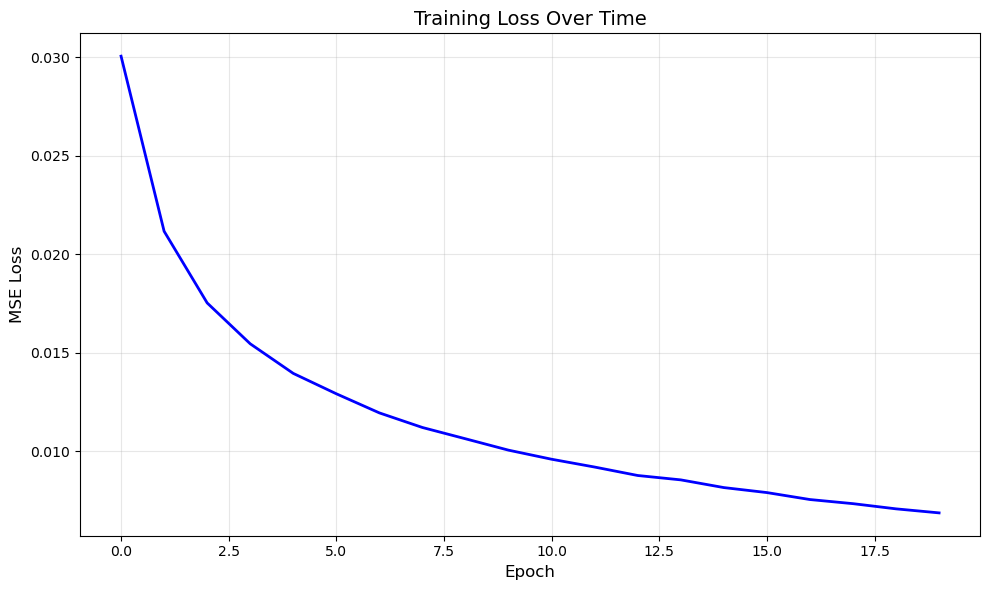

Output 1: Loss curve showing decreasing loss
Initial loss: 0.030064
Final loss: 0.006883
Loss decreased by: 0.023182


In [22]:
# Plot loss curve (Required Output 1)

plt.figure(figsize=(10, 6))
plt.plot(loss_history, color='blue', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Training Loss Over Time', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Output 1: Loss curve showing decreasing loss")
print(f"Initial loss: {loss_history[0]:.6f}")
print(f"Final loss: {loss_history[-1]:.6f}")
print(f"Loss decreased by: {loss_history[0] - loss_history[-1]:.6f}")

In [23]:
# REQUIRED OUTPUT 2: TEST ACCURACY
# Run forward pass on the 10,000 test images and compute classification accuracy
# The predicted class is the output neuron with the highest activation value

# Forward pass on all test images
_, _, _, _, _, A3_test = forward_pass(X_test, W1, b1, W2, b2, W3, b3)

# Predicted class = index of the highest output neuron
predicted_labels = np.argmax(A3_test, axis=1)   # shape: (10000,)

# Compare predictions to true test labels
correct    = np.sum(predicted_labels == Y_test)
total      = Y_test.shape[0]
accuracy   = correct / total * 100.0

print(f"\nTest Accuracy: {correct}/{total} = {accuracy:.2f}%")


Test Accuracy: 9579/10000 = 95.79%


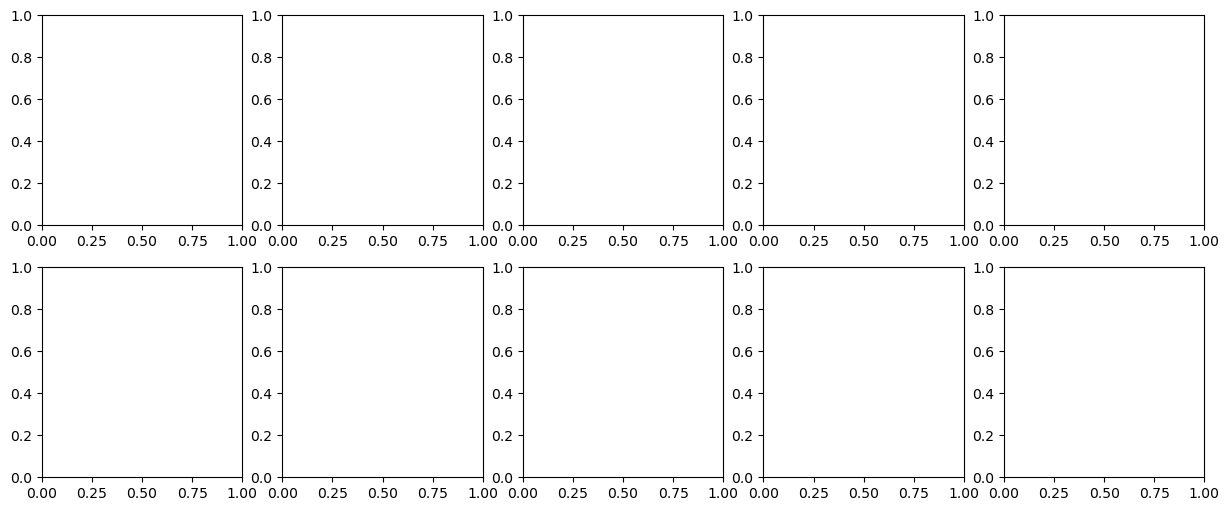

<class 'NameError'>: name 'test_predictions' is not defined

In [24]:
#Display 10 test images, one per digit (Required Output 3)

# Find one test image for each digit (0-9)
sample_indices = []
for digit in range(10):
    indices = np.where(Y_test == digit)[0]
    sample_indices.append(indices[0])

# Create figure with 2 rows and 5 columns
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

# Display each sample
for i, idx in enumerate(sample_indices):
    # Get the image (reshape from 784 to 28x28)
    image = X_test[idx].reshape(28, 28)
    true_label = Y_test[idx]
    pred_label = test_predictions[idx]
    
    # Display the image
    axes[i].imshow(image, cmap='gray')
    
    # Set title with true and predicted labels
    if true_label == pred_label:
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', 
                         fontsize=12, color='green')
    else:
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', 
                         fontsize=12, color='red')
    
    axes[i].axis('off')

plt.suptitle('Output 3: Sample Test Images with Predictions', fontsize=14)
plt.tight_layout()
plt.show()

print("Output 3: Displayed 10 test images (one per digit class)")
print("Green titles = correct predictions")
print("Red titles = incorrect predictions")